# 🔬 RGB Benchmark Evaluation — Progressive Experiments Notebook
## Benchmarking LLM Abilities for Retrieval-Augmented Generation

**Paper:** [Benchmarking Large Language Models in RAG](https://arxiv.org/pdf/2309.01431)  
**Dataset:** [RGB GitHub Repository](https://github.com/chen700564/RGB)  
**API:** OpenRouter (OpenAI-compatible)

---

### Experiment Progression (Token-Credit-Efficient)

| # | Experiment | Model | Samples | Prompt | Purpose |
|---|-----------|-------|---------|--------|---------|
| 1 | **Baseline Quick** | llama-3.1-8b (cheapest) | 20/ability | Basic | Verify pipeline works, get baseline |
| 2 | **Baseline Full** | llama-3.1-8b | ALL | Basic | Full baseline numbers for report |
| 3 | **Mid-Tier Model** | gemma-2-9b-it | ALL | Basic | Compare model size effect |
| 4 | **Large Model** | deepseek-r1-distill-llama-70b | ALL | Basic | Best available model |
| 5 | **Prompt Engineering** | Best model from #2-4 | ALL | CoT + Few-shot | Show improvement via prompts |
| 6 | **Final Comparison** | All models | ALL | Best prompt | Generate report-ready tables & charts |

> **Start from Experiment 1** and work your way down. Each experiment saves CSV + charts locally.  
> Stop whenever you've used enough credits.

### 4 Abilities Tested (per RGB paper)
| # | Ability | Metric | Dataset File |
|---|---------|--------|-------------|
| 1 | Noise Robustness | Accuracy | en.json (300 Q) |
| 2 | Negative Rejection | Rejection Rate | en.json (300 Q, negative docs only) |
| 3 | Information Integration | Accuracy | en_int.json (100 Q) |
| 4 | Counterfactual Robustness | Error Detection Rate + Error Correction Rate | en_fact.json (100 Q) |


## 1. Environment Setup

In [21]:
# Install required packages
!pip install -q openai pandas matplotlib seaborn tqdm


In [22]:
import json
import os
import re
import time
import hashlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from openai import OpenAI
from tqdm import tqdm
from collections import defaultdict
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Create output directories
os.makedirs('rgb_data', exist_ok=True)
os.makedirs('results', exist_ok=True)
os.makedirs('charts', exist_ok=True)

print('✅ All imports successful!')
print(f'📁 Output folders created: rgb_data/, results/, charts/')


✅ All imports successful!
📁 Output folders created: rgb_data/, results/, charts/


## 2. OpenRouter Configuration

Set your OpenRouter API key below. Get one free at [openrouter.ai/keys](https://openrouter.ai/keys).

**Available models (cheapest → most expensive):**



In [47]:
# ============================================================
# ⚙️ CONFIGURATION — Set your API key and model choices here
# ============================================================

# --- API Setup (reads from Colab Secrets) ---
from google.colab import userdata

OPENROUTER_API_KEY = userdata.get('OPENROUTER_API_KEY')  # Add this key in Colab Secrets (🔑 icon in sidebar)

if not OPENROUTER_API_KEY:
    raise ValueError(
        "❌ OPENROUTER_API_KEY not found in Colab Secrets.\n"
        "➡️  Click the 🔑 icon in the left sidebar → 'Add new secret' → Name: OPENROUTER_API_KEY"
    )

# Initialize OpenAI-compatible client pointing to OpenRouter
client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
)

# --- Model Registry (cheapest first) ---
MODELS = {
    "llama-3.1-8b":    "meta-llama/llama-3.1-8b-instruct",
    "gemma-3-12b":     "google/gemma-3-12b-it",                # Mid-tier
    "gemma-4-31b":     "google/gemma-4-31b-it",
    "qwen3-32b":       "qwen/qwen3-32b",
    "llama-3.3-70b":   "meta-llama/llama-3.3-70b-instruct",
    "deepseek-r1-70b": "deepseek/deepseek-r1-distill-llama-70b",
}

# --- Rate Limiting ---
MIN_DELAY_BETWEEN_CALLS = 0.3   # Seconds between API calls
MAX_RETRIES = 5                  # Retries on rate limit

print(f"✅ OpenRouter client initialized (key loaded from Colab Secrets)")
print(f"📋 Available models: {list(MODELS.keys())}")

✅ OpenRouter client initialized (key loaded from Colab Secrets)
📋 Available models: ['llama-3.1-8b', 'gemma-3-12b', 'gemma-4-31b', 'qwen3-32b', 'llama-3.3-70b', 'deepseek-r1-70b']


## 3. Download & Load RGB Dataset

The RGB dataset lives on GitHub. It has 3 JSON files for English:
- `en.json` → Noise Robustness (300 Q) + Negative Rejection (same Q, negative docs only)
- `en_int.json` → Information Integration (100 Q)
- `en_fact.json` → Counterfactual Robustness (100 Q)


In [24]:
# Download RGB dataset from GitHub
import urllib.request

RGB_FILES = {
    'en':      'https://raw.githubusercontent.com/chen700564/RGB/refs/heads/master/data/en.json',
    'en_int':  'https://raw.githubusercontent.com/chen700564/RGB/refs/heads/master/data/en_int.json',
    'en_fact': 'https://raw.githubusercontent.com/chen700564/RGB/refs/heads/master/data/en_fact.json',
}

for name, url in RGB_FILES.items():
    filepath = f'rgb_data/{name}.json'
    if not os.path.exists(filepath):
        print(f'Downloading {name}.json ...')
        try:
            urllib.request.urlretrieve(url, filepath)
            print(f'  ✅ Saved to {filepath}')
        except Exception as e:
            print(f'  ❌ Error: {e}')
    else:
        print(f'  ✅ {filepath} already exists')


  ✅ rgb_data/en.json already exists
  ✅ rgb_data/en_int.json already exists
  ✅ rgb_data/en_fact.json already exists


In [25]:
# Load datasets
def load_rgb_jsonl(filepath):
    """Load JSONL file (one JSON object per line)."""
    data = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if line:
                data.append(json.loads(line))
    return data

data_en   = load_rgb_jsonl('rgb_data/en.json')
data_int  = load_rgb_jsonl('rgb_data/en_int.json')
data_fact = load_rgb_jsonl('rgb_data/en_fact.json')

print(f'en.json      : {len(data_en)} questions  (Noise Robustness + Negative Rejection)')
print(f'en_int.json  : {len(data_int)} questions  (Information Integration)')
print(f'en_fact.json : {len(data_fact)} questions  (Counterfactual Robustness)')
print(f'Total English questions: {len(data_en) + len(data_int) + len(data_fact)}')


en.json      : 300 questions  (Noise Robustness + Negative Rejection)
en_int.json  : 100 questions  (Information Integration)
en_fact.json : 100 questions  (Counterfactual Robustness)
Total English questions: 500


In [26]:
# Explore dataset structure
print('=' * 60)
print('SAMPLE FROM en.json')
print('=' * 60)
sample = data_en[0]
print(f'Keys: {list(sample.keys())}')
for k, v in sample.items():
    print(f'  {k}: {type(v).__name__} = {str(v)[:150]}')
print(f'  Positive docs: {len(sample.get("positive", []))}')
print(f'  Negative docs: {len(sample.get("negative", []))}')

print('\n' + '=' * 60)
print('SAMPLE FROM en_int.json')
print('=' * 60)
sample_int = data_int[0]
for k, v in sample_int.items():
    print(f'  {k}: {type(v).__name__} = {str(v)[:150]}')
if 'positive' in sample_int and isinstance(sample_int['positive'][0], list):
    print(f'  ⚠️  positive is NESTED (list of doc groups)')

print('\n' + '=' * 60)
print('SAMPLE FROM en_fact.json')
print('=' * 60)
sample_fact = data_fact[0]
for k, v in sample_fact.items():
    print(f'  {k}: {type(v).__name__} = {str(v)[:150]}')
print(f'  positive_wrong docs: {len(sample_fact.get("positive_wrong", []))}')


SAMPLE FROM en.json
Keys: ['id', 'query', 'answer', 'positive', 'negative']
  id: int = 0
  query: str = When is the premiere of 'Carole King & James Taylor: Just Call Out My Name'?
  answer: list = [['January 2 2022', 'Jan 2, 2022', 'Jan. 2, 2022', 'January 2, 2022', '2 January 2022', '2 Jan, 2022', '2 Jan., 2022', '2 January, 2022']]
  positive: list = ['However, the concert tour took place in honor of the 40th anniversary. The two might have aged since they first performed together but neither Carol
  negative: list = ['By   \tAlthea Legaspi  Carole King and James Taylor perform their own hits — alongside harmonizing on each other’s songs — in the new trailer for co
  Positive docs: 5
  Negative docs: 35

SAMPLE FROM en_int.json
  id: int = 0
  query: str = Who is the director of 'Carole King & James Taylor: Just Call Out My Name' and when is its premiere?
  answer: list = [['January 2 2022', 'Jan 2, 2022', 'Jan. 2, 2022', 'January 2, 2022', '2 January 2022', '2 Jan, 2022', '2 Jan.,

## 4. Core Helper Functions

### 4a. LLM Call Wrapper
OpenRouter is OpenAI-compatible. This wrapper handles:
- Rate limiting with exponential backoff
- Token tracking for credit monitoring
- Response caching to avoid re-spending credits on re-runs


In [48]:
# ============================================================
# LLM Call Wrapper — with rate limiting, caching, token tracking
# ============================================================

# Global token counter — tracks spending across all experiments
token_tracker = {"prompt_tokens": 0, "completion_tokens": 0, "total_calls": 0, "errors": 0}

# Simple disk cache: avoid re-paying for identical calls on re-run
_cache_file = "results/llm_cache.json"
if os.path.exists(_cache_file):
    with open(_cache_file, 'r') as f:
        _llm_cache = json.load(f)
    print(f"📦 Loaded {len(_llm_cache)} cached LLM responses")
else:
    _llm_cache = {}

def _cache_key(model, system, user):
    raw = f"{model}||{system}||{user}"
    return hashlib.md5(raw.encode()).hexdigest()

def _save_cache():
    with open(_cache_file, 'w') as f:
        json.dump(_llm_cache, f)


def call_llm(model_id, system_prompt, user_prompt,
             temperature=0.1, max_tokens=200):
    """
    Call OpenRouter LLM with caching, rate limiting, and token tracking.
    Returns generated text or None on failure.
    """
    # Check cache first — saves credits on re-runs
    ck = _cache_key(model_id, system_prompt, user_prompt)
    if ck in _llm_cache:
        return _llm_cache[ck]

    for attempt in range(MAX_RETRIES):
        try:
            time.sleep(MIN_DELAY_BETWEEN_CALLS)
            response = client.chat.completions.create(
                model=model_id,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user",   "content": user_prompt},
                ],
                temperature=temperature,
                max_tokens=max_tokens,
            )
            text = response.choices[0].message.content.strip()

            # Track tokens
            usage = response.usage
            if usage:
                token_tracker["prompt_tokens"]     += usage.prompt_tokens or 0
                token_tracker["completion_tokens"]  += usage.completion_tokens or 0
            token_tracker["total_calls"] += 1

            # Cache result
            _llm_cache[ck] = text
            if token_tracker["total_calls"] % 20 == 0:
                _save_cache()  # Periodic save

            return text

        except Exception as e:
            err = str(e).lower()
            if any(k in err for k in ['429', 'rate', 'too many', 'quota']):
                wait = (2 ** attempt) * 5
                print(f"    ⏳ Rate limited (attempt {attempt+1}/{MAX_RETRIES}). Waiting {wait}s...")
                time.sleep(wait)
            else:
                print(f"    ❌ API error: {str(e)[:200]}")
                token_tracker["errors"] += 1
                return None

    token_tracker["errors"] += 1
    return None


def print_token_usage():
    """Print current token usage summary."""
    t = token_tracker
    print(f"\n📊 Token Usage So Far:")
    print(f"   Prompt tokens:     {t['prompt_tokens']:,}")
    print(f"   Completion tokens: {t['completion_tokens']:,}")
    print(f"   Total tokens:      {t['prompt_tokens'] + t['completion_tokens']:,}")
    print(f"   API calls:         {t['total_calls']:,}")
    print(f"   Errors:            {t['errors']}")
    print(f"   Cached responses:  {len(_llm_cache)}")


# Quick test
test_model = MODELS["llama-3.1-8b"]
test_resp = call_llm(test_model, "You are helpful.", "Say hello in exactly 5 words.")
print(f"Test response: {test_resp}")
print_token_usage()


📦 Loaded 801 cached LLM responses
Test response: Hello, how are you today?

📊 Token Usage So Far:
   Prompt tokens:     0
   Completion tokens: 0
   Total tokens:      0
   API calls:         0
   Errors:            0
   Cached responses:  801


### 4b. Document Extraction Helpers
Each ability uses different document keys from the RGB dataset.

In [28]:
# ============================================================
# Document Extractors — one per ability
# ============================================================

def extract_question(item):
    for key in ['question', 'query', 'input']:
        if key in item:
            return item[key]
    return None

def extract_answer(item):
    for key in ['answer', 'answers', 'gold_answer', 'target']:
        if key in item:
            val = item[key]
            return val if isinstance(val, list) else [val]
    return []

def get_noise_robustness_docs(item):
    """Positive (relevant) + negative (noisy) documents."""
    return item.get('positive', []) + item.get('negative', [])

def get_negative_rejection_docs(item):
    """ONLY negative (irrelevant) documents — LLM should refuse."""
    return item.get('negative', [])

def get_integration_docs(item):
    """Flatten nested positive + negative docs."""
    positive = item.get('positive', [])
    negative = item.get('negative', [])
    flat_positive = []
    for p in positive:
        if isinstance(p, list):
            flat_positive.extend(p)
        else:
            flat_positive.append(p)
    return flat_positive + negative

def get_counterfactual_docs(item):
    """Documents with deliberate factual errors."""
    return item.get('positive_wrong', [])

def build_document_context(documents):
    """Format document list into a numbered context string."""
    parts = []
    for i, doc in enumerate(documents, 1):
        text = doc.get('text', doc.get('content', str(doc))) if isinstance(doc, dict) else str(doc)
        parts.append(f"Document [{i}]: {text}")
    return "\n\n".join(parts)

# Validate
s = data_en[0]
print(f"Q: {extract_question(s)[:80]}...")
print(f"A: {extract_answer(s)}")
print(f"Noise docs: {len(get_noise_robustness_docs(s))}")
print(f"Neg docs:   {len(get_negative_rejection_docs(s))}")
s2 = data_int[0]
print(f"Integ docs: {len(get_integration_docs(s2))}")
s3 = data_fact[0]
print(f"CF docs:    {len(get_counterfactual_docs(s3))}")


Q: When is the premiere of 'Carole King & James Taylor: Just Call Out My Name'?...
A: [['January 2 2022', 'Jan 2, 2022', 'Jan. 2, 2022', 'January 2, 2022', '2 January 2022', '2 Jan, 2022', '2 Jan., 2022', '2 January, 2022']]
Noise docs: 40
Neg docs:   35
Integ docs: 18
CF docs:    3


### 4c. Evaluation Metric Functions
Each ability has its own metric, exactly as defined in the RGB paper.

In [29]:
# ============================================================
# Evaluation Metrics — per RGB paper Section 3.2
# ============================================================

def check_accuracy(response, gt_answers):
    """Noise Robustness accuracy: exact match of any GT answer in response."""
    if not response:
        return 0
    resp = response.lower().strip()
    for ans in gt_answers:
        if isinstance(ans, list):
            for a in ans:
                if str(a).lower().strip() in resp:
                    return 1
        else:
            if str(ans).lower().strip() in resp:
                return 1
    return 0

def check_integration_accuracy(response, gt_answers):
    """Info Integration: ALL answer components must be found in response."""
    if not response:
        return 0
    resp = response.lower().strip()
    for component in gt_answers:
        if isinstance(component, list):
            if not any(str(v).lower().strip() in resp for v in component):
                return 0
        else:
            if str(component).lower().strip() not in resp:
                return 0
    return 1

def check_rejection(response):
    """Negative Rejection: did the LLM refuse to answer?"""
    if not response:
        return 0
    resp = response.lower()
    phrases = [
        'i can not answer', 'i cannot answer', 'cannot be answered',
        'insufficient information', 'not enough information',
        'no relevant information', 'unable to answer',
        'do not have enough', "don't have enough",
        'documents do not contain', "documents don't contain",
        'not mentioned in', 'no answer can be found',
        'no information available',
    ]
    return 1 if any(p in resp for p in phrases) else 0

def check_error_detection(response):
    """Counterfactual: did the LLM detect factual errors?"""
    if not response:
        return 0
    resp = response.lower()
    phrases = [
        'factual error', 'factually incorrect', 'incorrect information',
        'inaccurate information', 'error in the', 'errors in the',
        'not accurate', 'is incorrect', 'are incorrect',
        'contains an error', 'contain errors', 'factual inaccuracy',
        'misinformation', 'wrong information',
    ]
    return 1 if any(p in resp for p in phrases) else 0

def check_error_correction(response, gt_answers):
    """Counterfactual: did the LLM still give the correct answer?"""
    return check_accuracy(response, gt_answers)

# Quick tests
print("Accuracy test:", check_accuracy("The answer is Paris", ["Paris"]))
print("Rejection test:", check_rejection("I cannot answer the question"))
print("Detection test:", check_error_detection("There are factual errors in the documents"))
print("Integration (both found):", check_integration_accuracy(
    "Frank Marshall directed it, released January 2, 2022",
    [["January 2, 2022", "Jan 2 2022"], "Frank Marshall"]))
print("Integration (one missing):", check_integration_accuracy(
    "It was released January 2, 2022",
    [["January 2, 2022"], "Frank Marshall"]))
print("✅ All metric functions verified")


Accuracy test: 1
Rejection test: 1
Detection test: 1
Integration (both found): 1
Integration (one missing): 0
✅ All metric functions verified


### 4d. Prompt Templates
We define **two prompt styles** — Basic (cheap baseline) and CoT (improved, for later experiments).

In [50]:
# ============================================================
# PROMPT TEMPLATES
# ============================================================

# --- Style 1: BASIC (minimal tokens, used in Experiments 1-4) ---
PROMPTS_BASIC = {
    "noise_robustness": {
        "system": "You are a helpful assistant. Answer the question based on the given documents. Only give the answer, no extra words.",
        "user": "Given the following documents, answer the question.\n\n{context}\n\nQuestion: {question}\nAnswer:",
    },
    "negative_rejection": {
        "system": "You are a helpful assistant. Answer based ONLY on the given documents. If the documents do not contain enough information, respond EXACTLY with: \"I can not answer the question because of insufficient information in documents.\"",
        "user": "Given the following documents, answer the question. If the documents don't have the answer, say \"I can not answer the question because of insufficient information in documents.\"\n\n{context}\n\nQuestion: {question}\nAnswer:",
    },
    "information_integration": {
        "system": "You are a helpful assistant. Answer the question by combining information from multiple documents. Give a concise answer.",
        "user": "Given the following documents, answer the question by synthesizing information across documents.\n\n{context}\n\nQuestion: {question}\nAnswer:",
    },
    "counterfactual_robustness": {
        "system": "You are a helpful assistant. Answer based on the given documents. WARNING: Some documents may contain factual errors. If you detect errors, first say \"There are factual errors in the provided documents.\" then give the correct answer.",
        "user": "Given the following documents, answer the question. If you find factual errors, first state \"There are factual errors in the provided documents.\" then answer correctly.\n\n{context}\n\nQuestion: {question}\nAnswer:",
    },
}

# --- Style 2: CHAIN-OF-THOUGHT (used in Experiment 5) ---
PROMPTS_COT = {
    "noise_robustness": {
        "system": """You are a careful analytical assistant. Answer the question based on the given documents.
Think step by step:
1. Read each document and determine if it is relevant to the question.
2. Ignore irrelevant documents completely.
3. Extract the answer from relevant documents only.
4. State the final answer clearly and concisely.
Keep your reasoning brief — max 2-3 sentences, then give the final answer.""",
        "user": "Documents:\n{context}\n\nQuestion: {question}\n\nLet me analyze each document step by step:\n",
    },
    "negative_rejection": {
        "system": """You are a careful analytical assistant. Answer based ONLY on the given documents.
Think step by step:
1. Read each document carefully.
2. Check if ANY document contains information relevant to the question.
3. If NO document is relevant, you MUST respond: "I can not answer the question because of insufficient information in documents."
4. Do NOT guess or use your own knowledge.""",
        "user": "Documents:\n{context}\n\nQuestion: {question}\n\nLet me check each document for relevance:\n",
    },
    "information_integration": {
        "system": """You are a careful analytical assistant. Answer by combining information from multiple documents.
Think step by step:
1. Identify which documents contain parts of the answer.
2. Extract the relevant pieces from each document.
3. Combine them into a complete answer.
4. Make sure your answer includes ALL required parts.""",
        "user": "Documents:\n{context}\n\nQuestion: {question}\n\nLet me find and combine information from multiple documents:\n",
    },
    "counterfactual_robustness": {
        "system": """You are a careful fact-checking assistant.
Think step by step:
1. Read each document and cross-check the facts against your knowledge.
2. If you find any factual errors, state: "There are factual errors in the provided documents."
3. Then provide the CORRECT answer based on your knowledge, not the wrong document.
4. If all facts check out, just answer the question.""",
        "user": "Documents:\n{context}\n\nQuestion: {question}\n\nLet me fact-check each document:\n",
    },
}

# --- Style 3: FEW-SHOT (used in Experiment 5 for rejection & counterfactual) ---
FEWSHOT_REJECTION_EXAMPLES = """
Example 1:
Documents: [Document about cooking pasta recipes]
Question: What is the capital of France?
Analysis: I checked every document. None mention France, capitals, or geography.
Answer: I can not answer the question because of insufficient information in documents.

Example 2:
Documents: [Document about smartphone battery technology]
Question: Who won the 2022 FIFA World Cup?
Analysis: Documents only discuss batteries and charging. No sports content found.
Answer: I can not answer the question because of insufficient information in documents.

Example 3:
Documents: [Documents about a music concert tour dates]
Question: What is the population of Tokyo?
Analysis: Documents cover concert events only. Population data is absent entirely.
Answer: I can not answer the question because of insufficient information in documents.

IMPORTANT: If no document contains information directly relevant to the question,
you MUST respond with exactly: "I can not answer the question because of insufficient information in documents."
Do NOT guess. Do NOT use outside knowledge.

Now answer the following:
"""

FEWSHOT_COUNTERFACTUAL_EXAMPLES = """
Example 1:
Documents: [Document stating "The Eiffel Tower is located in London"]
Question: Where is the Eiffel Tower located?
Answer: There are factual errors in the provided documents. The Eiffel Tower is located in Paris, France.

Now answer the following:
"""

print("✅ Prompt templates defined:")
print(f"   Basic prompts:  {list(PROMPTS_BASIC.keys())}")
print(f"   CoT prompts:    {list(PROMPTS_COT.keys())}")
print(f"   Few-shot:       rejection + counterfactual examples")


✅ Prompt templates defined:
   Basic prompts:  ['noise_robustness', 'negative_rejection', 'information_integration', 'counterfactual_robustness']
   CoT prompts:    ['noise_robustness', 'negative_rejection', 'information_integration', 'counterfactual_robustness']
   Few-shot:       rejection + counterfactual examples


### 4e. Core Evaluation Engine
A single generic function that runs any ability × model × prompt-style combination.
Results auto-save to CSV after every experiment.


In [31]:
# ============================================================
# GENERIC EVALUATION ENGINE
# ============================================================

# Map ability -> (dataset, doc_extractor, metric_function(s))
ABILITY_CONFIG = {
    "noise_robustness": {
        "data": "en",
        "get_docs": get_noise_robustness_docs,
        "check": lambda resp, gt: {"correct": check_accuracy(resp, gt)},
        "aggregate": lambda results: {"accuracy": sum(r["correct"] for r in results) / max(len(results), 1)},
    },
    "negative_rejection": {
        "data": "en",
        "get_docs": get_negative_rejection_docs,
        "check": lambda resp, gt: {"rejected": check_rejection(resp)},
        "aggregate": lambda results: {"rejection_rate": sum(r["rejected"] for r in results) / max(len(results), 1)},
    },
    "information_integration": {
        "data": "int",
        "get_docs": get_integration_docs,
        "check": lambda resp, gt: {"correct": check_integration_accuracy(resp, gt)},
        "aggregate": lambda results: {"accuracy": sum(r["correct"] for r in results) / max(len(results), 1)},
    },
    "counterfactual_robustness": {
        "data": "fact",
        "get_docs": get_counterfactual_docs,
        "check": lambda resp, gt: {
            "error_detected": check_error_detection(resp),
            "error_corrected": check_error_correction(resp, gt),
        },
        "aggregate": lambda results: {
            "error_detection_rate": sum(r["error_detected"] for r in results) / max(len(results), 1),
            "error_correction_rate": sum(r["error_corrected"] for r in results) / max(len(results), 1),
        },
    },
}

DATASETS = {"en": data_en, "int": data_int, "fact": data_fact}


def run_ability_evaluation(
    ability: str,
    model_key: str,
    prompt_style: str = "basic",
    max_samples: int = None,
    fewshot_prefix: str = "",
):
    """
    Run evaluation for one ability × one model × one prompt style.

    Args:
        ability: one of noise_robustness, negative_rejection, etc.
        model_key: key from MODELS dict (e.g., "llama-3.1-8b")
        prompt_style: "basic" or "cot"
        max_samples: limit samples (None = all)
        fewshot_prefix: optional few-shot examples to prepend to user prompt

    Returns:
        (detail_results_list, aggregate_metrics_dict)
    """
    cfg = ABILITY_CONFIG[ability]
    model_id = MODELS[model_key]
    prompts = PROMPTS_COT if prompt_style == "cot" else PROMPTS_BASIC
    sys_prompt = prompts[ability]["system"]
    usr_template = prompts[ability]["user"]

    data = DATASETS[cfg["data"]]
    if max_samples:
        data = data[:max_samples]

    print(f"\n{'─'*50}")
    print(f"  {ability} | {model_key} | {prompt_style} | {len(data)} samples")
    print(f"{'─'*50}")

    results = []
    for i, item in enumerate(tqdm(data, desc=f"  {ability[:15]}", leave=False)):
        question = extract_question(item)
        gt_answers = extract_answer(item)
        documents = cfg["get_docs"](item)

        if not question or not documents:
            continue

        context = build_document_context(documents)
        user_prompt = fewshot_prefix + usr_template.format(context=context, question=question)

        response = call_llm(model_id, sys_prompt, user_prompt)
        metrics = cfg["check"](response, gt_answers)

        row = {
            "index": i,
            "question": question[:120],
            "gt_answer": str(gt_answers)[:100],
            "response": (response or "FAILED")[:300],
            **metrics,
        }
        results.append(row)

    # Aggregate
    agg = cfg["aggregate"](results)

    # Print summary
    for k, v in agg.items():
        print(f"  ✅ {k}: {v:.4f} ({int(v * len(results))}/{len(results)})")

    return results, agg


print("✅ Evaluation engine ready")


✅ Evaluation engine ready


### 4f. Experiment Runner & Auto-Save
Wraps the evaluation engine into a single function that runs all 4 abilities for a given config and auto-saves everything.


In [32]:
# ============================================================
# EXPERIMENT RUNNER — runs all 4 abilities and saves results
# ============================================================

# Master results store — accumulates across all experiments
all_experiment_results = []   # List of summary rows
all_detail_results = {}       # exp_name -> {ability -> detail_list}

def run_experiment(
    experiment_name: str,
    model_key: str,
    prompt_style: str = "basic",
    max_samples: int = None,
    fewshot_map: dict = None,
):
    """
    Run all 4 RGB abilities for one experiment configuration.
    Saves CSV + prints summary.

    Args:
        experiment_name: e.g., "Exp1_Baseline_Quick"
        model_key: key from MODELS dict
        prompt_style: "basic" or "cot"
        max_samples: limit per ability (None = all)
        fewshot_map: {ability: fewshot_prefix_str} for few-shot experiments
    """
    print(f"\n{'='*60}")
    print(f"  EXPERIMENT: {experiment_name}")
    print(f"  Model: {model_key} ({MODELS[model_key]})")
    print(f"  Prompt: {prompt_style} | Samples: {max_samples or 'ALL'}")
    print(f"{'='*60}")

    abilities = [
        "noise_robustness",
        "negative_rejection",
        "information_integration",
        "counterfactual_robustness",
    ]

    summary = {
        "experiment": experiment_name,
        "model": model_key,
        "prompt_style": prompt_style,
        "max_samples": max_samples or "ALL",
    }
    detail = {}

    for ability in abilities:
        fewshot = ""
        if fewshot_map and ability in fewshot_map:
            fewshot = fewshot_map[ability]

        results, agg = run_ability_evaluation(
            ability=ability,
            model_key=model_key,
            prompt_style=prompt_style,
            max_samples=max_samples,
            fewshot_prefix=fewshot,
        )

        # Store per-ability metrics in summary
        for k, v in agg.items():
            summary[f"{ability}__{k}"] = round(v, 4)

        detail[ability] = results

    # Save to master store
    all_experiment_results.append(summary)
    all_detail_results[experiment_name] = detail

    # Auto-save summary CSV
    df_summary = pd.DataFrame(all_experiment_results)
    df_summary.to_csv("results/rgb_summary_all_experiments.csv", index=False)

    # Auto-save detail CSVs per ability
    for ability, res_list in detail.items():
        df_detail = pd.DataFrame(res_list)
        fname = f"results/{experiment_name}_{ability}.csv"
        df_detail.to_csv(fname, index=False)

    # Save cache
    _save_cache()

    # Print summary
    print(f"\n{'─'*50}")
    print(f"  📊 {experiment_name} — RESULTS SUMMARY")
    print(f"{'─'*50}")
    for k, v in summary.items():
        if k not in ["experiment", "model", "prompt_style", "max_samples"]:
            ability_name = k.split("__")[0].replace("_", " ").title()
            metric_name = k.split("__")[1].replace("_", " ").title()
            print(f"  {ability_name} → {metric_name}: {v:.4f}")

    print_token_usage()
    print(f"\n  💾 Results saved to results/ folder")

    return summary


print("✅ run_experiment() ready — runs all 4 abilities and auto-saves")


✅ run_experiment() ready — runs all 4 abilities and auto-saves


In [33]:
import os
import zipfile
from google.colab import files
from datetime import datetime
def download_results(results_dir='/content/results', prefix='experiment'):
    """Zip all files in results_dir and trigger a browser download."""
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    zip_name = f'/content/{prefix}_{timestamp}.zip'
    with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
        for root, dirs, filenames in os.walk(results_dir):
            for fname in filenames:
                full_path = os.path.join(root, fname)
                arcname = os.path.relpath(full_path, results_dir)
                zf.write(full_path, arcname)
    size_mb = os.path.getsize(zip_name) / (1024 * 1024)
    print(f"✅ Zipped {zip_name} ({size_mb:.2f} MB)")
    files.download(zip_name)

---
## 🧪 Experiment 1: Baseline Quick Test (Cheapest Model, 20 Samples)

**Purpose:** Verify the pipeline works end-to-end. Uses the cheapest model with just 20 samples per ability.

| Parameter | Value |
|-----------|-------|
| Model | llama-3.1-8b (cheapest @ $0.06/M tokens) |
| Samples | 20 per ability |
| Prompt | Basic (minimal tokens) |
| Estimated cost | ~$0.01 |


In [15]:
# ============================================================
# EXPERIMENT 1: Baseline Quick — Cheapest model, 20 samples
# ============================================================
exp1 = run_experiment(
    experiment_name="Exp1_Baseline_Quick",
    model_key="llama-3.1-8b",
    prompt_style="basic",
    max_samples=20,
)



  EXPERIMENT: Exp1_Baseline_Quick
  Model: llama-3.1-8b (meta-llama/llama-3.1-8b-instruct)
  Prompt: basic | Samples: 20

──────────────────────────────────────────────────
  noise_robustness | llama-3.1-8b | basic | 20 samples
──────────────────────────────────────────────────


  ✅ accuracy: 0.8500 (17/20)

──────────────────────────────────────────────────
  negative_rejection | llama-3.1-8b | basic | 20 samples
──────────────────────────────────────────────────


  ✅ rejection_rate: 0.4500 (9/20)

──────────────────────────────────────────────────
  information_integration | llama-3.1-8b | basic | 20 samples
──────────────────────────────────────────────────


  ✅ accuracy: 0.7000 (14/20)

──────────────────────────────────────────────────
  counterfactual_robustness | llama-3.1-8b | basic | 20 samples
──────────────────────────────────────────────────


  ✅ error_detection_rate: 0.6500 (13/20)
  ✅ error_correction_rate: 0.4500 (9/20)

──────────────────────────────────────────────────
  📊 Exp1_Baseline_Quick — RESULTS SUMMARY
──────────────────────────────────────────────────
  Noise Robustness → Accuracy: 0.8500
  Negative Rejection → Rejection Rate: 0.4500
  Information Integration → Accuracy: 0.7000
  Counterfactual Robustness → Error Detection Rate: 0.6500
  Counterfactual Robustness → Error Correction Rate: 0.4500

📊 Token Usage So Far:
   Prompt tokens:     521,075
   Completion tokens: 3,273
   Total tokens:      524,348
   API calls:         81
   Errors:            0
   Cached responses:  81

  💾 Results saved to results/ folder


---
## 🧪 Experiment 2: Baseline 50 (Cheapest Model, 50 Samples)
**Purpose:** Get stable baseline numbers with more data than Exp 1.
| Parameter | Value |
|-----------|-------|
| Model | llama-3.1-8b (cheapest @ $0.06/M tokens) |
| Samples | 50 per ability |
| Prompt | Basic |

In [17]:
# ============================================================
# EXPERIMENT 2: Baseline Full — Cheapest model, ALL samples
# ============================================================
exp2 = run_experiment(
    experiment_name="Exp2_Baseline_50",
    model_key="llama-3.1-8b",
    prompt_style="basic",
    max_samples=50,
)



  EXPERIMENT: Exp2_Baseline_50
  Model: llama-3.1-8b (meta-llama/llama-3.1-8b-instruct)
  Prompt: basic | Samples: 50

──────────────────────────────────────────────────
  noise_robustness | llama-3.1-8b | basic | 50 samples
──────────────────────────────────────────────────


  ✅ accuracy: 0.9200 (46/50)

──────────────────────────────────────────────────
  negative_rejection | llama-3.1-8b | basic | 50 samples
──────────────────────────────────────────────────


  ✅ rejection_rate: 0.5000 (25/50)

──────────────────────────────────────────────────
  information_integration | llama-3.1-8b | basic | 50 samples
──────────────────────────────────────────────────


  ✅ accuracy: 0.7200 (36/50)

──────────────────────────────────────────────────
  counterfactual_robustness | llama-3.1-8b | basic | 50 samples
──────────────────────────────────────────────────


  ✅ error_detection_rate: 0.5200 (26/50)
  ✅ error_correction_rate: 0.3400 (17/50)

──────────────────────────────────────────────────
  📊 Exp2_Baseline_50 — RESULTS SUMMARY
──────────────────────────────────────────────────
  Noise Robustness → Accuracy: 0.9200
  Negative Rejection → Rejection Rate: 0.5000
  Information Integration → Accuracy: 0.7200
  Counterfactual Robustness → Error Detection Rate: 0.5200
  Counterfactual Robustness → Error Correction Rate: 0.3400

📊 Token Usage So Far:
   Prompt tokens:     1,262,189
   Completion tokens: 8,207
   Total tokens:      1,270,396
   API calls:         201
   Errors:            0
   Cached responses:  201

  💾 Results saved to results/ folder


---
## 🧪 Experiment 3: Mid-Tier Model (gemma-3-12b, 50 Samples)

**Purpose:** Compare a different architecture (Google Gemma) against the Llama baseline.

| Parameter | Value |
|-----------|-------|
| Model | google/gemma-3-12b-it (12B) |
| Samples | 50 per ability |
| Prompt | Basic |
| Estimated cost | ~$0.10 |


In [39]:
# ============================================================
# EXPERIMENT 3: Mid-Tier — gemma-3-12b, 50 samples
# ============================================================
exp3 = run_experiment(
    experiment_name="Exp3_MidTier_Gemma12b",
    model_key="gemma-3-12b",
    prompt_style="basic",
    max_samples=50,
)


  EXPERIMENT: Exp3_MidTier_Gemma12b
  Model: gemma-3-12b (google/gemma-3-12b-it)
  Prompt: basic | Samples: 50

──────────────────────────────────────────────────
  noise_robustness | gemma-3-12b | basic | 50 samples
──────────────────────────────────────────────────


  ✅ accuracy: 0.9400 (47/50)

──────────────────────────────────────────────────
  negative_rejection | gemma-3-12b | basic | 50 samples
──────────────────────────────────────────────────


  ✅ rejection_rate: 0.1600 (8/50)

──────────────────────────────────────────────────
  information_integration | gemma-3-12b | basic | 50 samples
──────────────────────────────────────────────────


  ✅ accuracy: 0.8200 (41/50)

──────────────────────────────────────────────────
  counterfactual_robustness | gemma-3-12b | basic | 50 samples
──────────────────────────────────────────────────


  ✅ error_detection_rate: 0.9000 (45/50)
  ✅ error_correction_rate: 0.6200 (31/50)

──────────────────────────────────────────────────
  📊 Exp3_MidTier_Gemma12b — RESULTS SUMMARY
──────────────────────────────────────────────────
  Noise Robustness → Accuracy: 0.9400
  Negative Rejection → Rejection Rate: 0.1600
  Information Integration → Accuracy: 0.8200
  Counterfactual Robustness → Error Detection Rate: 0.9000
  Counterfactual Robustness → Error Correction Rate: 0.6200

📊 Token Usage So Far:
   Prompt tokens:     1,331,778
   Completion tokens: 7,456
   Total tokens:      1,339,234
   API calls:         200
   Errors:            4
   Cached responses:  401

  💾 Results saved to results/ folder


---
## 🧪 Experiment 4: Large Model (gemma-4-31b, 50 Samples)

**Purpose:** Test a 4× larger model to see the ceiling performance.

| Parameter | Value |
|-----------|-------|
| Model | google/gemma-4-31b-it (31B, paid) |
| Samples | 50 per ability |
| Prompt | Basic |
| Estimated cost | ~$0.15 |

In [42]:
# ============================================================
# EXPERIMENT 4: Large Model — gemma-4-31b (paid), 50 samples
# ============================================================
exp4 = run_experiment(
    experiment_name="Exp4_Large_Gemma31b",
    model_key="gemma-4-31b",
    prompt_style="basic",
    max_samples=50,
)
download_results('/content/results', prefix='Exp4_Large_Gemma31b')


  EXPERIMENT: Exp4_Large_Gemma31b
  Model: gemma-4-31b (google/gemma-4-31b-it)
  Prompt: basic | Samples: 50

──────────────────────────────────────────────────
  noise_robustness | gemma-4-31b | basic | 50 samples
──────────────────────────────────────────────────


  ✅ accuracy: 1.0000 (50/50)

──────────────────────────────────────────────────
  negative_rejection | gemma-4-31b | basic | 50 samples
──────────────────────────────────────────────────


  ✅ rejection_rate: 0.2200 (11/50)

──────────────────────────────────────────────────
  information_integration | gemma-4-31b | basic | 50 samples
──────────────────────────────────────────────────


  ✅ accuracy: 0.9200 (46/50)

──────────────────────────────────────────────────
  counterfactual_robustness | gemma-4-31b | basic | 50 samples
──────────────────────────────────────────────────


  ✅ error_detection_rate: 0.8400 (42/50)
  ✅ error_correction_rate: 0.5600 (28/50)

──────────────────────────────────────────────────
  📊 Exp4_Large_Gemma31b — RESULTS SUMMARY
──────────────────────────────────────────────────
  Noise Robustness → Accuracy: 1.0000
  Negative Rejection → Rejection Rate: 0.2200
  Information Integration → Accuracy: 0.9200
  Counterfactual Robustness → Error Detection Rate: 0.8400
  Counterfactual Robustness → Error Correction Rate: 0.5600

📊 Token Usage So Far:
   Prompt tokens:     2,665,912
   Completion tokens: 16,629
   Total tokens:      2,682,541
   API calls:         400
   Errors:            4
   Cached responses:  601

  💾 Results saved to results/ folder
✅ Zipped /content/Exp4_Large_Gemma31b_20260816_200525.zip (0.11 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 🧪 Experiment 4b (Optional): Qwen3-32b

| Parameter | Value |
|-----------|-------|
| Model | qwen3-32b |
| Samples | ALL |
| Prompt | Basic |

> Skip this if you want to save credits. 3 models (Exp 2-4) are enough for a good comparison.


In [ ]:
# ============================================================
# EXPERIMENT 4b: Qwen3-32b (OPTIONAL — uncomment to run)
# ============================================================
# exp4b = run_experiment(
#     experiment_name="Exp4b_Qwen3_32b",
#     model_key="qwen3-32b",
#     prompt_style="basic",
#     max_samples=None,
# )


---
## 🧪 Experiment 5: Prompt Engineering (CoT + Few-Shot)

**Purpose:** Show that prompt engineering can improve LLM abilities WITHOUT changing the model.  
This is a key finding for the report — same model, better prompts = better scores.

Uses the **best-performing model from Experiments 2-4** with:
- Chain-of-Thought (CoT) prompts for all 4 abilities
- Few-shot examples for Negative Rejection and Counterfactual Robustness

| Parameter | Value |
|-----------|-------|
| Model | Best from Exp 2-4 |
| Samples | ALL |
| Prompt | CoT + Few-shot |


In [44]:
# ============================================================
# EXPERIMENT 5a: CoT Prompts — same cheap model, better instructions
# ============================================================
# Using llama-3.1-8b to isolate prompt effect (same model as Exp 2)
# Key question: Can CoT fix Error Detection (52%) and Error Correction (34%)?

exp5a = run_experiment(
    experiment_name="Exp5a_CoT_Llama8b",
    model_key="llama-3.1-8b",
    prompt_style="cot",
    max_samples=50,
)
download_results('/content/results', prefix='Exp5a_CoT')


  EXPERIMENT: Exp5a_CoT_Llama8b
  Model: llama-3.1-8b (meta-llama/llama-3.1-8b-instruct)
  Prompt: cot | Samples: 50

──────────────────────────────────────────────────
  noise_robustness | llama-3.1-8b | cot | 50 samples
──────────────────────────────────────────────────


  ✅ accuracy: 0.9200 (46/50)

──────────────────────────────────────────────────
  negative_rejection | llama-3.1-8b | cot | 50 samples
──────────────────────────────────────────────────


  ✅ rejection_rate: 0.1400 (7/50)

──────────────────────────────────────────────────
  information_integration | llama-3.1-8b | cot | 50 samples
──────────────────────────────────────────────────


  ✅ accuracy: 0.7200 (36/50)

──────────────────────────────────────────────────
  counterfactual_robustness | llama-3.1-8b | cot | 50 samples
──────────────────────────────────────────────────


  ✅ error_detection_rate: 0.6800 (34/50)
  ✅ error_correction_rate: 0.4400 (22/50)

──────────────────────────────────────────────────
  📊 Exp5a_CoT_Llama8b — RESULTS SUMMARY
──────────────────────────────────────────────────
  Noise Robustness → Accuracy: 0.9200
  Negative Rejection → Rejection Rate: 0.1400
  Information Integration → Accuracy: 0.7200
  Counterfactual Robustness → Error Detection Rate: 0.6800
  Counterfactual Robustness → Error Correction Rate: 0.4400

📊 Token Usage So Far:
   Prompt tokens:     3,932,580
   Completion tokens: 91,629
   Total tokens:      4,024,209
   API calls:         600
   Errors:            4
   Cached responses:  801

  💾 Results saved to results/ folder
✅ Zipped /content/Exp5a_CoT_20260816_204652.zip (0.19 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [51]:
# ============================================================
# EXPERIMENT 5b: CoT + Few-Shot — fixing rejection while keeping
#                counterfactual gains from 5a
# ============================================================
# CoT helped:  Error Detection 52% → 68%, Correction 34% → 44%
# CoT hurt:    Negative Rejection 50% → 14%
# Goal of 5b:  Strong few-shot examples to push rejection back up
#              while keeping counterfactual improvements

exp5b = run_experiment(
    experiment_name="Exp5b_CoT_FewShot_Llama8b",
    model_key="llama-3.1-8b",
    prompt_style="cot",
    max_samples=50,
    fewshot_map={
        "negative_rejection": FEWSHOT_REJECTION_EXAMPLES,
        "counterfactual_robustness": FEWSHOT_COUNTERFACTUAL_EXAMPLES,
    },
)
download_results('/content/results', prefix='Exp5b_CoT_FewShot')


  EXPERIMENT: Exp5b_CoT_FewShot_Llama8b
  Model: llama-3.1-8b (meta-llama/llama-3.1-8b-instruct)
  Prompt: cot | Samples: 50

──────────────────────────────────────────────────
  noise_robustness | llama-3.1-8b | cot | 50 samples
──────────────────────────────────────────────────


  ✅ accuracy: 0.8200 (41/50)

──────────────────────────────────────────────────
  negative_rejection | llama-3.1-8b | cot | 50 samples
──────────────────────────────────────────────────


  ✅ rejection_rate: 0.4800 (24/50)

──────────────────────────────────────────────────
  information_integration | llama-3.1-8b | cot | 50 samples
──────────────────────────────────────────────────


  ✅ accuracy: 0.7200 (36/50)

──────────────────────────────────────────────────
  counterfactual_robustness | llama-3.1-8b | cot | 50 samples
──────────────────────────────────────────────────


  ✅ error_detection_rate: 0.5400 (27/50)
  ✅ error_correction_rate: 0.3400 (17/50)

──────────────────────────────────────────────────
  📊 Exp5b_CoT_FewShot_Llama8b — RESULTS SUMMARY
──────────────────────────────────────────────────
  Noise Robustness → Accuracy: 0.8200
  Negative Rejection → Rejection Rate: 0.4800
  Information Integration → Accuracy: 0.7200
  Counterfactual Robustness → Error Detection Rate: 0.5400
  Counterfactual Robustness → Error Correction Rate: 0.3400

📊 Token Usage So Far:
   Prompt tokens:     705,238
   Completion tokens: 23,547
   Total tokens:      728,785
   API calls:         150
   Errors:            0
   Cached responses:  951

  💾 Results saved to results/ folder
✅ Zipped /content/Exp5b_CoT_FewShot_20260816_210541.zip (0.23 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [52]:
download_results('/content/results', prefix='Exp')

✅ Zipped /content/Exp_20260816_211152.zip (0.23 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 📊 6. Results Summary & Visualization

All experiment results are auto-saved. This section generates report-ready charts and tables.


### 6a. Summary Table (All Experiments)

In [53]:
# ============================================================
# LOAD & DISPLAY ALL RESULTS
# ============================================================

df_all = pd.DataFrame(all_experiment_results)

# Clean up column names for display
display_cols = {
    "experiment": "Experiment",
    "model": "Model",
    "prompt_style": "Prompt",
    "noise_robustness__accuracy": "Noise Robustness\n(Accuracy)",
    "negative_rejection__rejection_rate": "Negative Rejection\n(Rejection Rate)",
    "information_integration__accuracy": "Info Integration\n(Accuracy)",
    "counterfactual_robustness__error_detection_rate": "Counterfactual\n(Detection Rate)",
    "counterfactual_robustness__error_correction_rate": "Counterfactual\n(Correction Rate)",
}

df_display = df_all.rename(columns=display_cols)
cols_to_show = [v for v in display_cols.values() if v in df_display.columns]
df_display = df_display[cols_to_show]

print("📊 RGB BENCHMARK — ALL EXPERIMENTS SUMMARY")
print("=" * 100)
display(df_display)

# Save final summary
df_all.to_csv("results/rgb_final_summary.csv", index=False)
print("\n💾 Saved: results/rgb_final_summary.csv")


📊 RGB BENCHMARK — ALL EXPERIMENTS SUMMARY


,Experiment,Model,Prompt,Noise Robustness\n(Accuracy),Negative Rejection\n(Rejection Rate),Info Integration\n(Accuracy),Counterfactual\n(Detection Rate),Counterfactual\n(Correction Rate)
0,Exp3_MidTier_Gemma,llama-3.1-8b,basic,0.92,0.50,0.72,0.52,0.34
1,Exp3_MidTier_Gemma12b,gemma-3-12b,basic,0.94,0.16,0.82,0.90,0.62
2,Exp4_Large_Gemma31b,gemma-4-31b,basic,1.00,0.22,0.92,0.84,0.56
3,Exp5a_CoT_Llama8b,llama-3.1-8b,cot,0.92,0.14,0.72,0.68,0.44
4,Exp5b_CoT_FewShot_Llama8b,llama-3.1-8b,cot,0.82,0.48,0.72,0.54,0.34



💾 Saved: results/rgb_final_summary.csv


### 6b. Chart 1: Model Comparison — Grouped Bar Chart

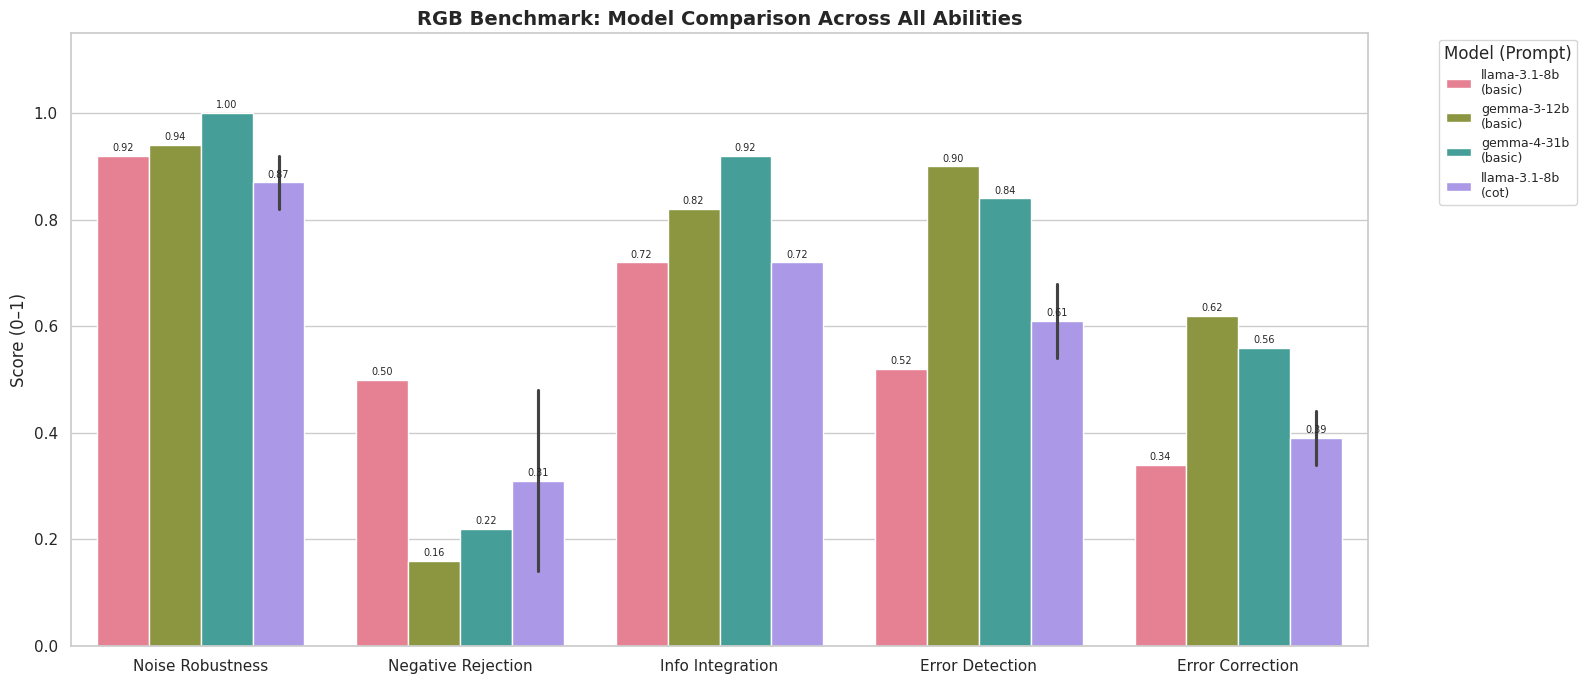

💾 Saved: charts/rgb_model_comparison.png


In [54]:
# ============================================================
# CHART 1: Model Comparison — All abilities side by side
# ============================================================

# Filter to full-sample experiments only (skip Exp1 quick test)
df_models = df_all[df_all["experiment"] != "Exp1_Baseline_Quick"].copy()

if df_models.empty:
    print("⚠️ No full-sample experiments found. Run Experiment 2+ first.")
else:
    # Prepare plot data
    plot_rows = []
    for _, row in df_models.iterrows():
        label = f"{row['model']}\n({row['prompt_style']})"
        if "noise_robustness__accuracy" in row:
            plot_rows.append({"Config": label, "Ability": "Noise Robustness", "Score": row["noise_robustness__accuracy"]})
        if "negative_rejection__rejection_rate" in row:
            plot_rows.append({"Config": label, "Ability": "Negative Rejection", "Score": row["negative_rejection__rejection_rate"]})
        if "information_integration__accuracy" in row:
            plot_rows.append({"Config": label, "Ability": "Info Integration", "Score": row["information_integration__accuracy"]})
        if "counterfactual_robustness__error_detection_rate" in row:
            plot_rows.append({"Config": label, "Ability": "Error Detection", "Score": row["counterfactual_robustness__error_detection_rate"]})
        if "counterfactual_robustness__error_correction_rate" in row:
            plot_rows.append({"Config": label, "Ability": "Error Correction", "Score": row["counterfactual_robustness__error_correction_rate"]})

    df_plot = pd.DataFrame(plot_rows)

    fig, ax = plt.subplots(figsize=(16, 7))
    sns.barplot(data=df_plot, x="Ability", y="Score", hue="Config", ax=ax, palette="husl")
    ax.set_title("RGB Benchmark: Model Comparison Across All Abilities", fontsize=14, fontweight="bold")
    ax.set_ylabel("Score (0–1)", fontsize=12)
    ax.set_xlabel("")
    ax.set_ylim(0, 1.15)
    ax.legend(title="Model (Prompt)", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", fontsize=7, padding=2)

    plt.tight_layout()
    plt.savefig("charts/rgb_model_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Saved: charts/rgb_model_comparison.png")


### 6c. Chart 2: Per-Ability Sub-Plots

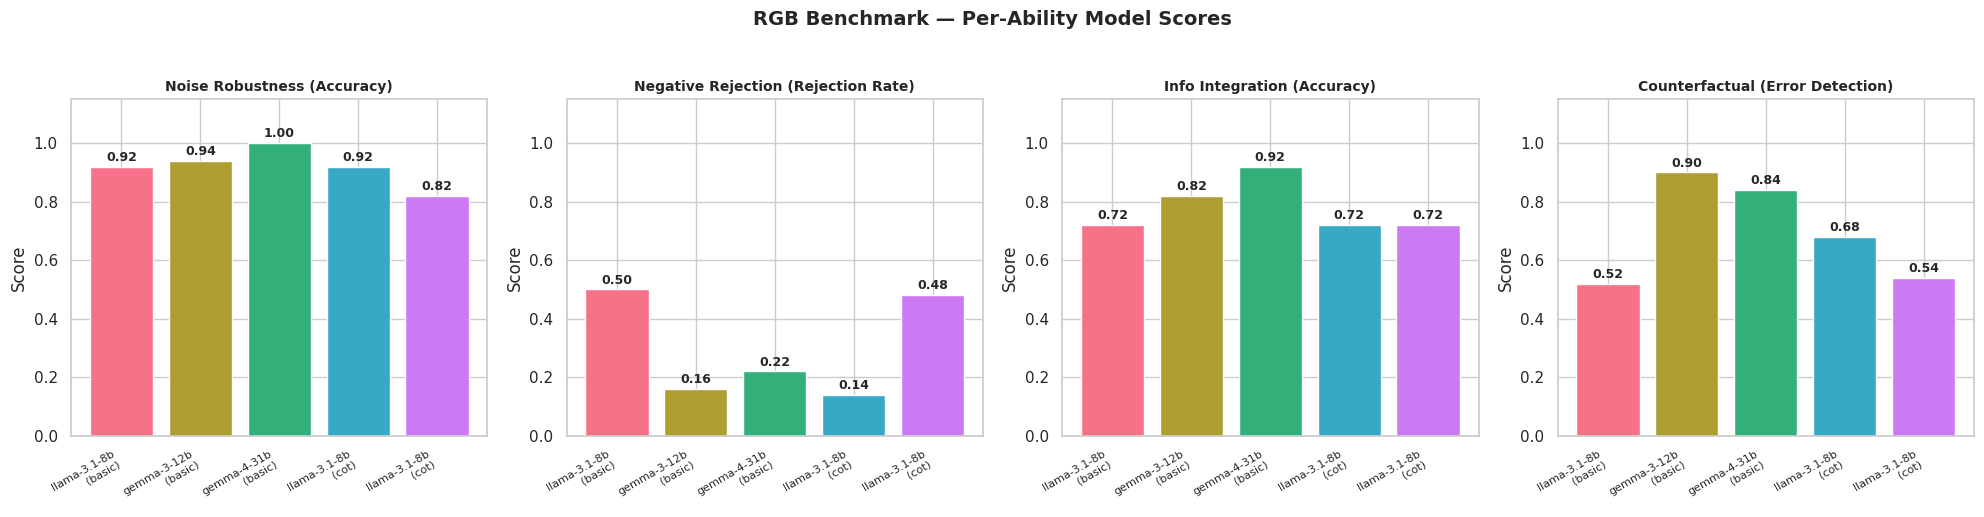

💾 Saved: charts/rgb_per_ability_charts.png


In [55]:
# ============================================================
# CHART 2: Individual bar charts per ability
# ============================================================

df_models = df_all[df_all["experiment"] != "Exp1_Baseline_Quick"].copy()

if df_models.empty:
    print("⚠️ Run full experiments first.")
else:
    abilities_chart = [
        ("Noise Robustness (Accuracy)", "noise_robustness__accuracy"),
        ("Negative Rejection (Rejection Rate)", "negative_rejection__rejection_rate"),
        ("Info Integration (Accuracy)", "information_integration__accuracy"),
        ("Counterfactual (Error Detection)", "counterfactual_robustness__error_detection_rate"),
    ]

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    colors = sns.color_palette("husl", len(df_models))

    for ax, (title, col) in zip(axes, abilities_chart):
        if col not in df_models.columns:
            continue
        labels = [f"{r['model']}\n({r['prompt_style']})" for _, r in df_models.iterrows()]
        scores = df_models[col].values
        bars = ax.bar(range(len(labels)), scores, color=colors)
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, fontsize=8, rotation=30, ha="right")
        ax.set_title(title, fontsize=10, fontweight="bold")
        ax.set_ylim(0, 1.15)
        ax.set_ylabel("Score")
        for bar, score in zip(bars, scores):
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                    f"{score:.2f}", ha="center", fontsize=9, fontweight="bold")

    plt.suptitle("RGB Benchmark — Per-Ability Model Scores", fontsize=14, fontweight="bold", y=1.03)
    plt.tight_layout()
    plt.savefig("charts/rgb_per_ability_charts.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Saved: charts/rgb_per_ability_charts.png")


### 6d. Chart 3: Prompt Engineering Effect (Basic vs CoT vs Few-Shot)

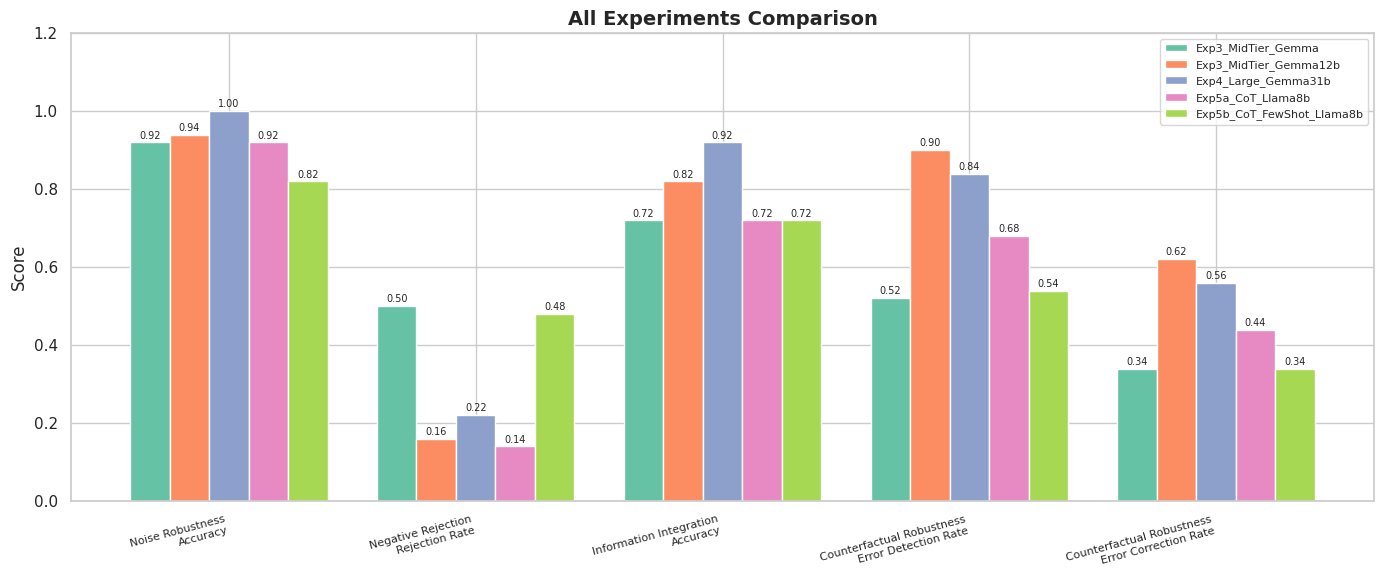

💾 Saved: charts/rgb_all_experiments_comparison.png


In [56]:
# ============================================================
# CHART 3: Prompt Engineering Effect — same model, different prompts
# ============================================================

# Find experiments with the same model but different prompt styles
df_prompt = df_all[df_all["experiment"] != "Exp1_Baseline_Quick"].copy()

if len(df_prompt) < 2:
    print("⚠️ Need at least 2 full experiments to compare. Run Exp 2-5.")
else:
    metric_cols = [c for c in df_prompt.columns if "__" in c]

    fig, ax = plt.subplots(figsize=(14, 6))

    x = np.arange(len(metric_cols))
    width = 0.8 / len(df_prompt)
    colors = sns.color_palette("Set2", len(df_prompt))

    for i, (_, row) in enumerate(df_prompt.iterrows()):
        label = f"{row['experiment']}"
        values = [row.get(c, 0) for c in metric_cols]
        offset = (i - len(df_prompt)/2 + 0.5) * width
        bars = ax.bar(x + offset, values, width, label=label, color=colors[i])
        for bar, val in zip(bars, values):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                        f"{val:.2f}", ha="center", fontsize=7)

    # Clean up x labels
    clean_labels = [c.replace("__", "\n").replace("_", " ").title() for c in metric_cols]
    ax.set_xticks(x)
    ax.set_xticklabels(clean_labels, fontsize=8, rotation=15, ha="right")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.2)
    ax.set_title("All Experiments Comparison", fontsize=14, fontweight="bold")
    ax.legend(fontsize=8, loc="upper right")

    plt.tight_layout()
    plt.savefig("charts/rgb_all_experiments_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Saved: charts/rgb_all_experiments_comparison.png")


### 6e. Chart 4: Heatmap — Models × Abilities

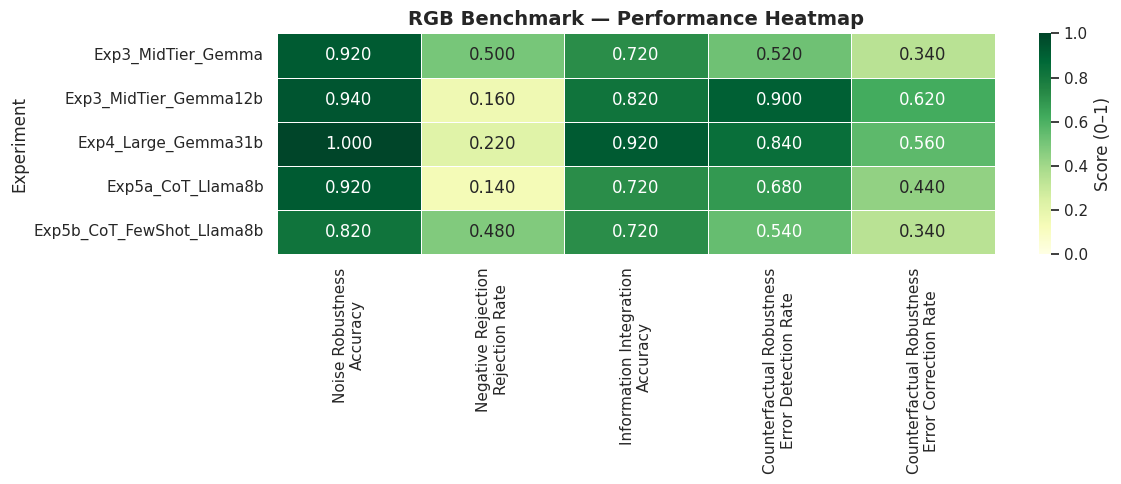

💾 Saved: charts/rgb_heatmap.png


In [57]:
# ============================================================
# CHART 4: Heatmap — clear visual for the report
# ============================================================

df_models = df_all[df_all["experiment"] != "Exp1_Baseline_Quick"].copy()

if df_models.empty:
    print("⚠️ Run full experiments first.")
else:
    metric_cols = [
        "noise_robustness__accuracy",
        "negative_rejection__rejection_rate",
        "information_integration__accuracy",
        "counterfactual_robustness__error_detection_rate",
        "counterfactual_robustness__error_correction_rate",
    ]
    available_cols = [c for c in metric_cols if c in df_models.columns]

    heatmap_data = df_models.set_index("experiment")[available_cols]
    heatmap_data.columns = [c.replace("__", "\n").replace("_", " ").title() for c in available_cols]

    fig, ax = plt.subplots(figsize=(12, max(3, len(heatmap_data) * 0.8 + 1)))
    sns.heatmap(
        heatmap_data.astype(float), annot=True, fmt=".3f", cmap="YlGn",
        vmin=0, vmax=1, linewidths=0.5, ax=ax,
        cbar_kws={"label": "Score (0–1)"}
    )
    ax.set_title("RGB Benchmark — Performance Heatmap", fontsize=14, fontweight="bold")
    ax.set_ylabel("Experiment")

    plt.tight_layout()
    plt.savefig("charts/rgb_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Saved: charts/rgb_heatmap.png")


### 6f. Detailed Sample Analysis — Failures & Insights

In [58]:
# ============================================================
# DETAILED ERROR ANALYSIS — for the report's qualitative section
# ============================================================

for exp_name, detail in all_detail_results.items():
    # Only show full experiments, skip quick test
    if "Quick" in exp_name:
        continue

    print(f"\n{'='*60}")
    print(f"  ERROR ANALYSIS: {exp_name}")
    print(f"{'='*60}")

    # Noise Robustness failures
    nr = detail.get("noise_robustness", [])
    if nr:
        incorrect = [r for r in nr if r.get("correct", 1) == 0]
        print(f"\n  📌 Noise Robustness — {len(incorrect)}/{len(nr)} INCORRECT")
        for r in incorrect[:3]:
            print(f"    Q: {r['question']}")
            print(f"    Expected: {r['gt_answer']}")
            print(f"    Got: {r['response'][:150]}")
            print()

    # Negative Rejection failures (LLM answered when it shouldn't)
    rej = detail.get("negative_rejection", [])
    if rej:
        not_rejected = [r for r in rej if r.get("rejected", 1) == 0]
        print(f"  📌 Negative Rejection — {len(not_rejected)}/{len(rej)} FAILED TO REJECT")
        for r in not_rejected[:3]:
            print(f"    Q: {r['question']}")
            print(f"    Response: {r['response'][:150]}")
            print()

    # Info Integration failures
    ii = detail.get("information_integration", [])
    if ii:
        ii_wrong = [r for r in ii if r.get("correct", 1) == 0]
        print(f"  📌 Info Integration — {len(ii_wrong)}/{len(ii)} INCORRECT")
        for r in ii_wrong[:3]:
            print(f"    Q: {r['question']}")
            print(f"    Expected: {r['gt_answer']}")
            print(f"    Got: {r['response'][:150]}")
            print()

    # Counterfactual: not detected
    cf = detail.get("counterfactual_robustness", [])
    if cf:
        not_detected = [r for r in cf if r.get("error_detected", 1) == 0]
        print(f"  📌 Counterfactual — {len(not_detected)}/{len(cf)} ERRORS NOT DETECTED")
        for r in not_detected[:3]:
            print(f"    Q: {r['question']}")
            print(f"    Response: {r['response'][:150]}")
            print()



  ERROR ANALYSIS: Exp3_MidTier_Gemma

  📌 Noise Robustness — 4/50 INCORRECT
    Q: Who won the 2022 Citrus Bowl?
    Expected: ['Kentucky Wildcats']
    Got: LSU

    Q: How many vehicles did Tesla deliver in 2021?
    Expected: [['936,172', '936172']]
    Got: 936,222

    Q: What is the price for a 30-second spot during the Super Bowl 2022?
    Expected: ['$6.5 million']
    Got: $7 million

  📌 Negative Rejection — 25/50 FAILED TO REJECT
    Q: When is the premiere of 'Carole King & James Taylor: Just Call Out My Name'?
    Response: Document [28]: Dec 21, 2021 ... Concert documentary 'Carole King & James Taylor: Just Call Out My Name' will premiere on Jan. 2 via CNN.

    Q: The genre of the drama "Good Sam" is what?
    Response: I can answer the question based on the documents.

The genre of the drama "Good Sam" is a family drama, as mentioned in Document [1] and Document [8].

    Q: Who won the 2022 Citrus Bowl?
    Response: LSU won the 2022 Citrus Bowl, defeating Purdue 63-7

---
## 7. Final Export — Download All Results

This cell packages everything into downloadable files.


In [59]:
# ============================================================
# FINAL EXPORT — Package all results for download
# ============================================================

# 1. Save final summary
df_final = pd.DataFrame(all_experiment_results)
df_final.to_csv("results/rgb_final_summary.csv", index=False)
print("✅ results/rgb_final_summary.csv")

# 2. Save full detailed results as JSON
full_output = {
    "metadata": {
        "project": "RGB Benchmark Evaluation",
        "date": datetime.now().isoformat(),
        "models_used": list(MODELS.keys()),
        "token_usage": token_tracker,
    },
    "experiments": all_experiment_results,
    "detail_results": {
        exp: {
            ability: results
            for ability, results in detail.items()
        }
        for exp, detail in all_detail_results.items()
    },
}

with open("results/rgb_full_results.json", "w") as f:
    json.dump(full_output, f, indent=2, default=str)
print("✅ results/rgb_full_results.json")

# 3. Save cache
_save_cache()
print(f"✅ results/llm_cache.json ({len(_llm_cache)} cached responses)")

# 4. List all output files
print("\n📁 All output files:")
for folder in ["results", "charts"]:
    if os.path.exists(folder):
        for f in sorted(os.listdir(folder)):
            fpath = os.path.join(folder, f)
            size = os.path.getsize(fpath)
            print(f"   {fpath} ({size:,} bytes)")

# 5. Final token usage
print_token_usage()


✅ results/rgb_final_summary.csv
✅ results/rgb_full_results.json
✅ results/llm_cache.json (951 cached responses)

📁 All output files:
   results/Exp1_Baseline_Quick_counterfactual_robustness.csv (5,426 bytes)
   results/Exp1_Baseline_Quick_information_integration.csv (6,362 bytes)
   results/Exp1_Baseline_Quick_negative_rejection.csv (4,016 bytes)
   results/Exp1_Baseline_Quick_noise_robustness.csv (2,491 bytes)
   results/Exp2_Baseline_50_counterfactual_robustness.csv (13,618 bytes)
   results/Exp2_Baseline_50_information_integration.csv (14,954 bytes)
   results/Exp2_Baseline_50_negative_rejection.csv (9,874 bytes)
   results/Exp2_Baseline_50_noise_robustness.csv (6,047 bytes)
   results/Exp3_MidTier_Gemma12b_counterfactual_robustness.csv (16,123 bytes)
   results/Exp3_MidTier_Gemma12b_information_integration.csv (14,151 bytes)
   results/Exp3_MidTier_Gemma12b_negative_rejection.csv (8,850 bytes)
   results/Exp3_MidTier_Gemma12b_noise_robustness.csv (5,595 bytes)
   results/Exp3_MidTi

In [60]:
# ============================================================
# DOWNLOAD FILES (Google Colab)
# ============================================================
# Uncomment the lines below to download in Colab:

from google.colab import files as colab_files

# Download summary CSV
colab_files.download("results/rgb_final_summary.csv")

# Download full JSON results
colab_files.download("results/rgb_full_results.json")

# Download charts
import glob
for chart_file in glob.glob("charts/*.png"):
    colab_files.download(chart_file)

# Download detail CSVs
for csv_file in glob.glob("results/Exp*.csv"):
    colab_files.download(csv_file)

print("✅ All files queued for download!")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files queued for download!


---
## Appendix A: Token Credit Budget Planner

| Experiment | Model | Samples | Est. Input Tokens | Est. Output Tokens | Est. Cost |
|-----------|-------|---------|-------------------|-------------------|-----------|
| Exp 1 (Quick) | llama-3.1-8b | 80 | ~120K | ~40K | ~$0.01 |
| Exp 2 (Full) | llama-3.1-8b | 800 | ~1.2M | ~400K | ~$0.10 |
| Exp 3 (Gemma) | gemma-2-9b | 800 | ~1.2M | ~400K | ~$0.13 |
| Exp 4 (DeepSeek) | deepseek-r1-70b | 800 | ~1.2M | ~400K | ~$0.55 |
| Exp 5a (CoT) | deepseek-r1-70b | 800 | ~1.5M | ~600K | ~$0.75 |
| Exp 5b (CoT+FS) | deepseek-r1-70b | 800 | ~1.6M | ~600K | ~$0.78 |
| **Total** | | | | | **~$2.32** |

> **With caching**, re-runs of completed experiments cost $0.  
> **Tip:** Run Exp 1 first to validate, then Exp 2-4 for the model comparison, then Exp 5 for the prompt engineering story.

## Appendix B: What Goes in Your Report

Based on the sample reports (Group 6 & Group 26), your RGB section should include:

### Required Tables
1. **Model Comparison Table** — All models × all abilities with scores (from `rgb_final_summary.csv`)
2. **Per-Ability Breakdown** — Detailed scores per model (from per-ability CSVs)

### Required Charts
1. **Grouped Bar Chart** — Models side by side for each ability (`rgb_model_comparison.png`)
2. **Per-Ability Sub-Plots** — Individual charts for Noise/Rejection/Integration/Counterfactual (`rgb_per_ability_charts.png`)
3. **Heatmap** — Visual summary across all experiments (`rgb_heatmap.png`)

### Required Analysis
1. **Which model performed best overall?** Compare across abilities.
2. **Which ability is hardest?** Usually Negative Rejection or Counterfactual.
3. **Did prompt engineering help?** Compare Exp 2-4 (basic) vs Exp 5 (CoT).
4. **Error analysis** — Show 2-3 examples where the LLM failed and explain why.

### Key Findings Template
> "Among the models tested, **[model]** achieved the highest Noise Robustness accuracy of **X%**,
> while **[model]** showed the best Negative Rejection rate of **Y%**.
> Chain-of-Thought prompting improved [ability] by **Z percentage points** over basic prompting."


## Appendix C: How to Run a Custom Experiment

To add your own experiment, just call `run_experiment()` with custom parameters:

```python
# Example: Test a new model with CoT prompts, limited to 50 samples
run_experiment(
    experiment_name="Exp_Custom_MyModel",
    model_key="qwen3-32b",        # Must be in MODELS dict
    prompt_style="cot",            # "basic" or "cot"
    max_samples=50,                # None for all
    fewshot_map={                   # Optional
        "negative_rejection": FEWSHOT_REJECTION_EXAMPLES,
    },
)
```

To add a new model, add it to the `MODELS` dict:
```python
MODELS["my-new-model"] = "provider/model-name-on-openrouter"
```
